In [24]:
import json
import pandas as pd
import matplotlib.pyplot as plt


def read_jsonl(path: str) -> pd.DataFrame:
    with open(path) as f:
        records = [json.loads(line) for line in f if line.strip()]
    return pd.DataFrame(records)


STRATEGIES = [
    "SAVINGS",
    "PATH_CHEAPEST_ARC",
    "SAVINGS_TABU_SEARCH",
    "PATH_CHEAPEST_ARC_TABU_SEARCH",
    "SAVINGS_GUIDED_LOCAL_SEARCH",
    "PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH",
]
COUNTS = [20, 50, 100]

frames = []
for strategy in STRATEGIES:
    for dynamic in (False, True):
        for n in COUNTS:
            kind = "dynamic" if dynamic else "static"
            df = read_jsonl(f"{strategy}/{strategy}_{kind}_{n}.jsonl")
            df = df[df["all_orders_delivered"]]
            df["strategy"] = strategy
            df["dynamic"] = dynamic
            frames.append(df)

all_runs = pd.concat(frames, ignore_index=True)

all_runs.head()


,timestamp,seed,replication_index,num_static_customers,num_dynamic_events,min_event_time,max_event_time,num_vehicles,num_orders_delivered,num_orders_total,all_orders_delivered,jain_fairness_index,total_makespan,truck_delivery_times,solve_times,reassigning_rates,strategy,dynamic
0,2026-07-29T09:46:33,0,0,20,4,0,0,4,24,24,True,0.499998,29356.084733,"{'TRUCK-2': 29356.08473348482, 'TRUCK-1': 29250.654499225846}",[0.07782662499812432],[],SAVINGS,False
1,2026-07-29T09:46:33,1,1,20,4,0,0,4,24,24,True,0.963054,15095.957777,"{'TRUCK-3': 8794.049485547795, 'TRUCK-1': 13491.108617930431, 'TRUCK-4': 15009.680662599898, 'TRUCK-2': 15095.957777097115}",[0.12786399998003617],[],SAVINGS,False
2,2026-07-29T09:46:33,2,2,20,4,0,0,4,24,24,True,0.976162,15029.915157,"{'TRUCK-3': 15029.915156875442, 'TRUCK-4': 14492.78791647285, 'TRUCK-2': 9785.743158184852, 'TRUCK-1': 14123.139830514425}",[0.06715200000326149],[],SAVINGS,False
3,2026-07-29T09:46:33,3,3,20,4,0,0,4,24,24,True,0.967315,14560.134324,"{'TRUCK-1': 14472.470114276362, 'TRUCK-3': 14560.134323736178, 'TRUCK-4': 9083.0535783013, 'TRUCK-2': 11491.77941947363}",[0.049538208986632526],[],SAVINGS,False
4,2026-07-29T09:46:33,4,4,20,4,0,0,4,24,24,True,0.740904,18158.212517,"{'TRUCK-1': 18158.21251700565, 'TRUCK-2': 17655.411309059706, 'TRUCK-3': 14026.310035385492}",[0.027437125012511387],[],SAVINGS,False


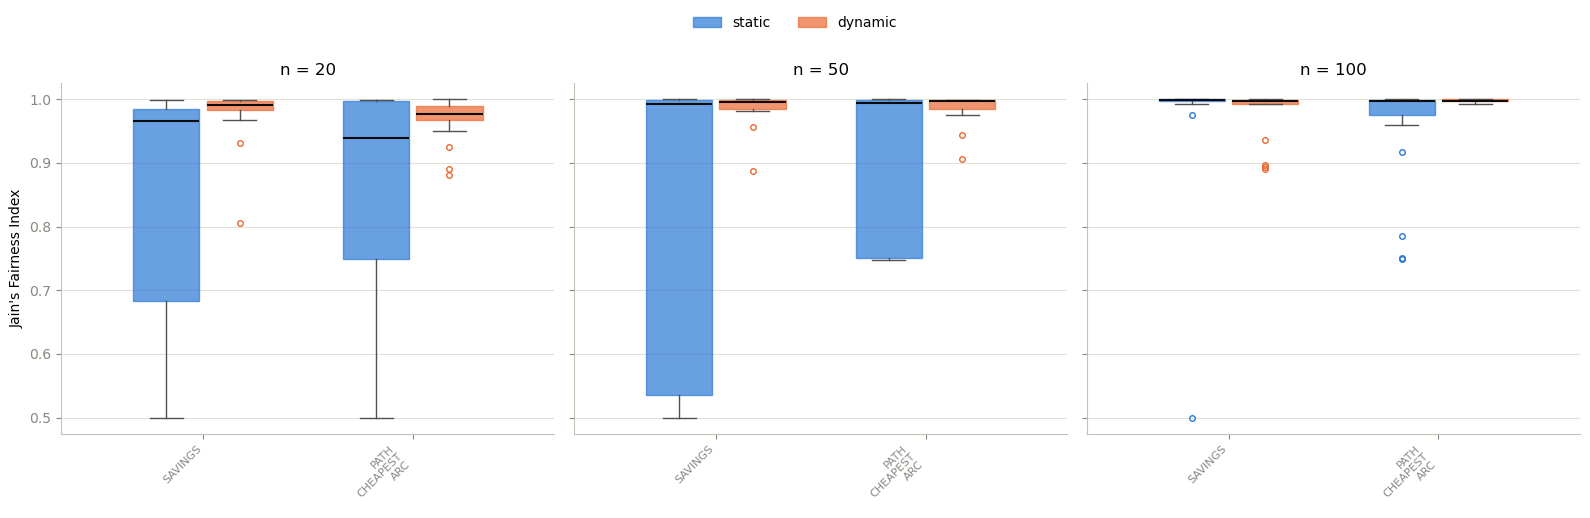

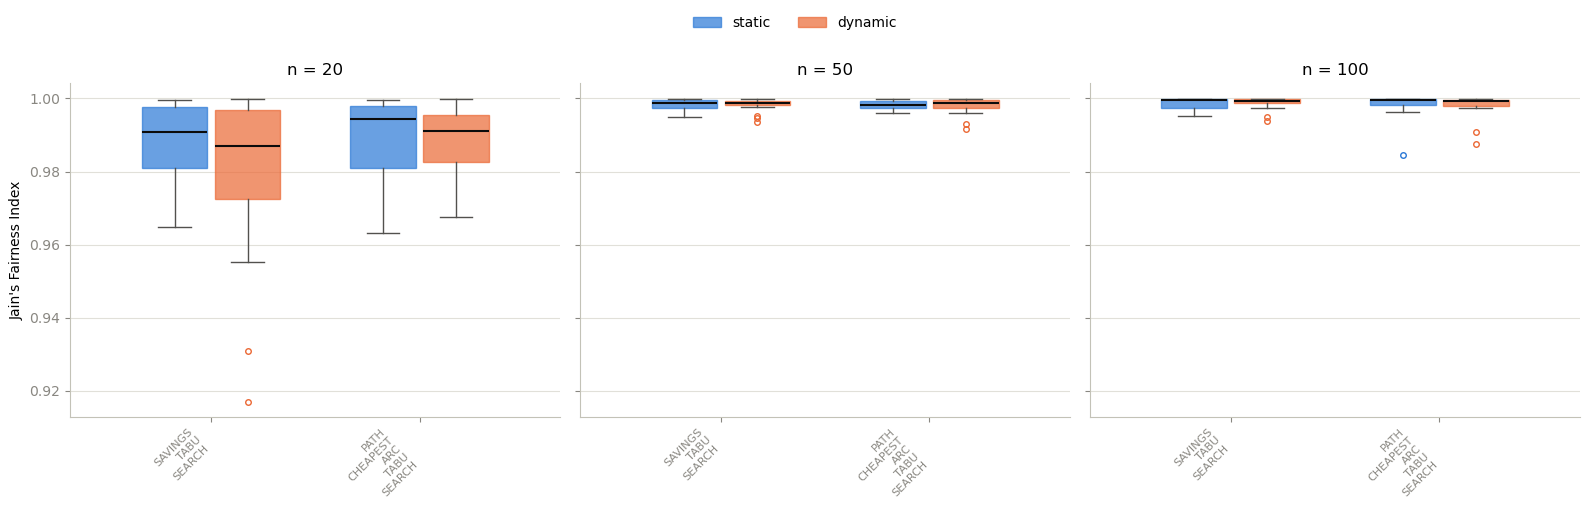

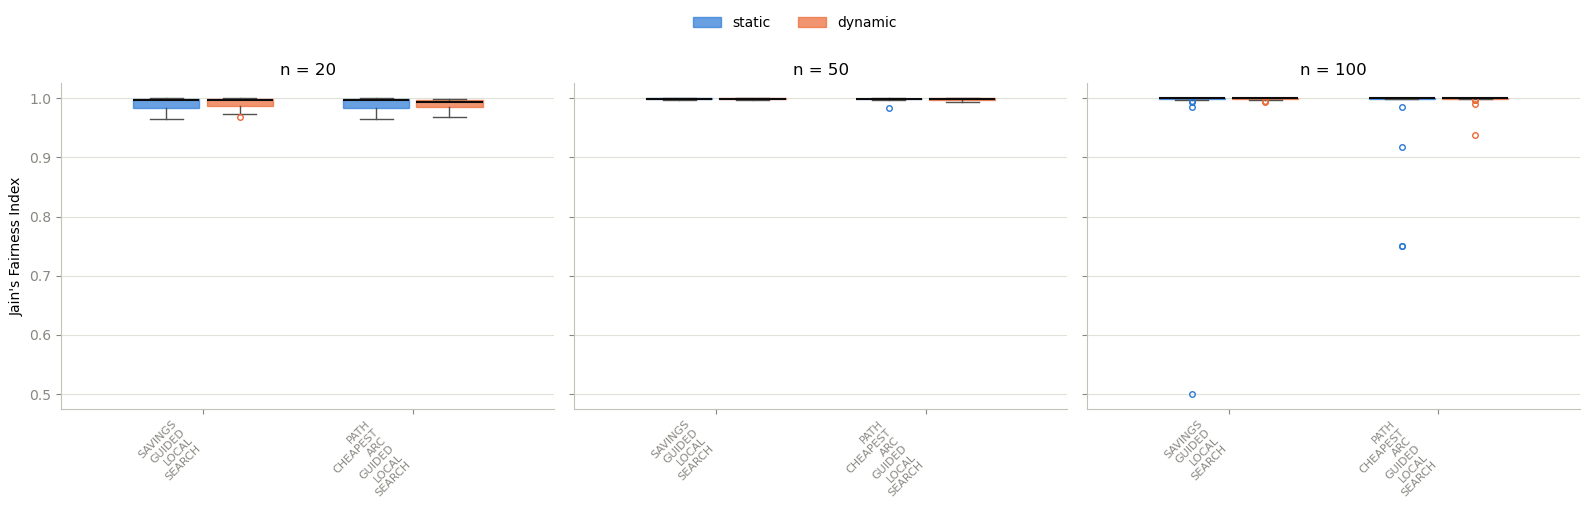

In [25]:
import numpy as np

width = 0.35
colors = {"static": "#2a78d6", "dynamic": "#eb6834"}


def plot_strategy_group(strategies):
    strategy_labels = [s.replace("_", "\n") for s in strategies]
    x = np.arange(len(strategies))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, n in zip(axes, COUNTS):
        subset = all_runs[all_runs["num_static_customers"] == n]
        static_data = [
            subset[(subset["strategy"] == s) & (~subset["dynamic"])]["jain_fairness_index"]
            for s in strategies
        ]
        dynamic_data = [
            subset[(subset["strategy"] == s) & (subset["dynamic"])]["jain_fairness_index"]
            for s in strategies
        ]

        bp_static = ax.boxplot(
            static_data,
            positions=x - width / 2,
            widths=width * 0.9,
            patch_artist=True,
            medianprops={"color": "#0b0b0b", "linewidth": 1.5},
            boxprops={"facecolor": colors["static"], "edgecolor": colors["static"], "alpha": 0.7},
            whiskerprops={"color": "#52514e"},
            capprops={"color": "#52514e"},
            flierprops={"markeredgecolor": colors["static"], "markersize": 4},
        )
        bp_dynamic = ax.boxplot(
            dynamic_data,
            positions=x + width / 2,
            widths=width * 0.9,
            patch_artist=True,
            medianprops={"color": "#0b0b0b", "linewidth": 1.5},
            boxprops={"facecolor": colors["dynamic"], "edgecolor": colors["dynamic"], "alpha": 0.7},
            whiskerprops={"color": "#52514e"},
            capprops={"color": "#52514e"},
            flierprops={"markeredgecolor": colors["dynamic"], "markersize": 4},
        )

        ax.set_xticks(x)
        ax.set_xticklabels(strategy_labels, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"n = {n}")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#898781")
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Jain's Fairness Index")

    fig.legend(
        [bp_static["boxes"][0], bp_dynamic["boxes"][0]],
        ["static", "dynamic"],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_strategy_group(["SAVINGS", "PATH_CHEAPEST_ARC"])
plot_strategy_group(["SAVINGS_TABU_SEARCH", "PATH_CHEAPEST_ARC_TABU_SEARCH"])
plot_strategy_group(["SAVINGS_GUIDED_LOCAL_SEARCH", "PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH"])


In [26]:
summary = (
    all_runs.assign(kind=all_runs["dynamic"].map({False: "static", True: "dynamic"}))
    .groupby(["strategy", "kind", "num_static_customers"])["jain_fairness_index"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)
summary


mean  \
strategy                              kind    num_static_customers          
PATH_CHEAPEST_ARC                     dynamic 20                    0.969   
                                              50                    0.986   
                                              100                   0.998   
                                      static  20                    0.861   
                                              50                    0.910   
                                              100                   0.955   
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH dynamic 20                    0.990   
                                              50                    0.998   
                                              100                   0.995   
                                      static  20                    0.989   
                                              50                    0.998   
                                              100                   0.970   
PATH_CHEAPEST_ARC_TABU_SEARCH         dynamic 20                    0.988   
                                              50                    0.998   
                                              100                   0.998   
                                      static  20                    0.988   
                                              50                    0.998   
                                              100                   0.998   
SAVINGS                               dynamic 20                    0.976   
                                              50                    0.986   
                                              100                   0.977   
                                      static  20                    0.816   
                                              50                    0.813   
                                              100                   0.972   
SAVINGS_GUIDED_LOCAL_SEARCH           dynamic 20                    0.992   
                                              50                    0.999   
                                              100                   0.999   
                                      static  20                    0.989   
                                              50                    0.999   
                                              100                   0.973   
SAVINGS_TABU_SEARCH                   dynamic 20                    0.980   
                                              50                    0.998   
                                              100                   0.999   
                                      static  20                    0.987   
                                              50                    0.998   
                                              100                   0.999   

                                                                    median  \
strategy                              kind    num_static_customers           
PATH_CHEAPEST_ARC                     dynamic 20                     0.977   
                                              50                     0.997   
                                              100                    0.998   
                                      static  20                     0.940   
                                              50                     0.994   
                                              100                    0.998   
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH dynamic 20                     0.994   
                                              50                     0.999   
                                              100                    0.999   
                                      static  20                     0.997   
                                              50                     0.999   
                                              100                    1.000   
PATH_CHEAPEST_ARC_TABU_SEARCH         dynamic 20  

In [27]:
pd.set_option("display.max_colwidth", None)

all_runs["total_distance"] = all_runs["truck_delivery_times"].apply(lambda d: sum(d.values()))

all_runs[["strategy", "dynamic", "num_static_customers", "total_makespan", "truck_delivery_times","total_distance"]].head()


,strategy,dynamic,num_static_customers,total_makespan,truck_delivery_times,total_distance
0,SAVINGS,False,20,29356.084733,"{'TRUCK-2': 29356.08473348482, 'TRUCK-1': 29250.654499225846}",58606.739233
1,SAVINGS,False,20,15095.957777,"{'TRUCK-3': 8794.049485547795, 'TRUCK-1': 13491.108617930431, 'TRUCK-4': 15009.680662599898, 'TRUCK-2': 15095.957777097115}",52390.796543
2,SAVINGS,False,20,15029.915157,"{'TRUCK-3': 15029.915156875442, 'TRUCK-4': 14492.78791647285, 'TRUCK-2': 9785.743158184852, 'TRUCK-1': 14123.139830514425}",53431.586062
3,SAVINGS,False,20,14560.134324,"{'TRUCK-1': 14472.470114276362, 'TRUCK-3': 14560.134323736178, 'TRUCK-4': 9083.0535783013, 'TRUCK-2': 11491.77941947363}",49607.437436
4,SAVINGS,False,20,18158.212517,"{'TRUCK-1': 18158.21251700565, 'TRUCK-2': 17655.411309059706, 'TRUCK-3': 14026.310035385492}",49839.933861


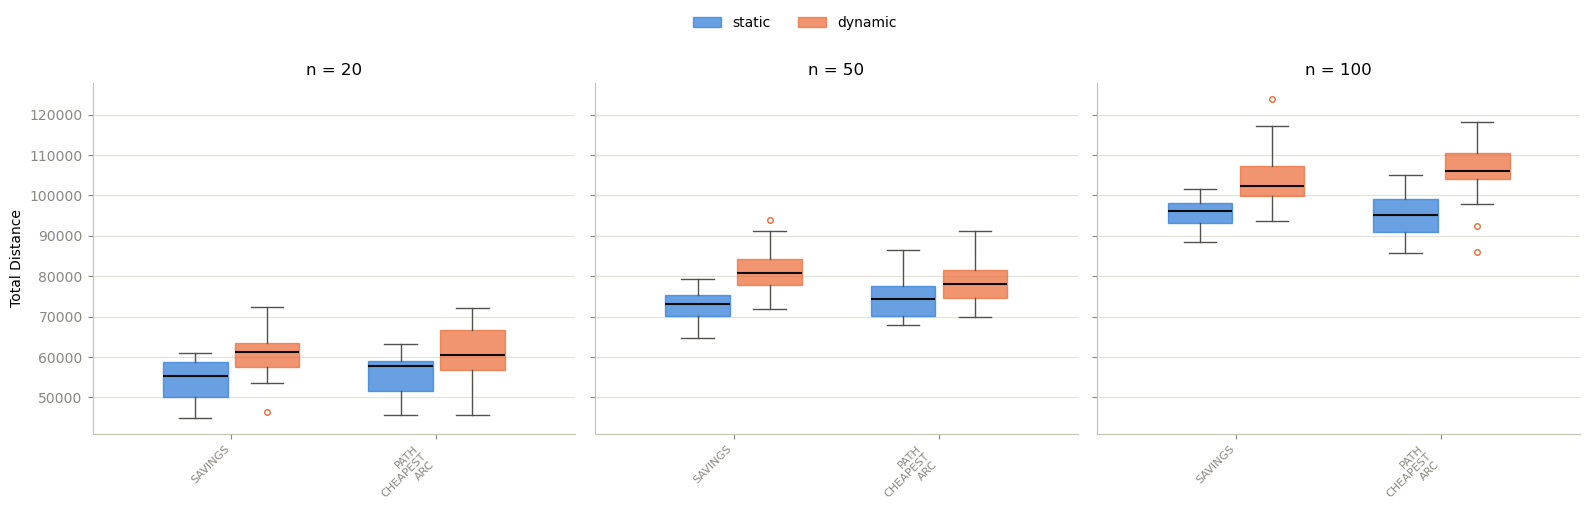

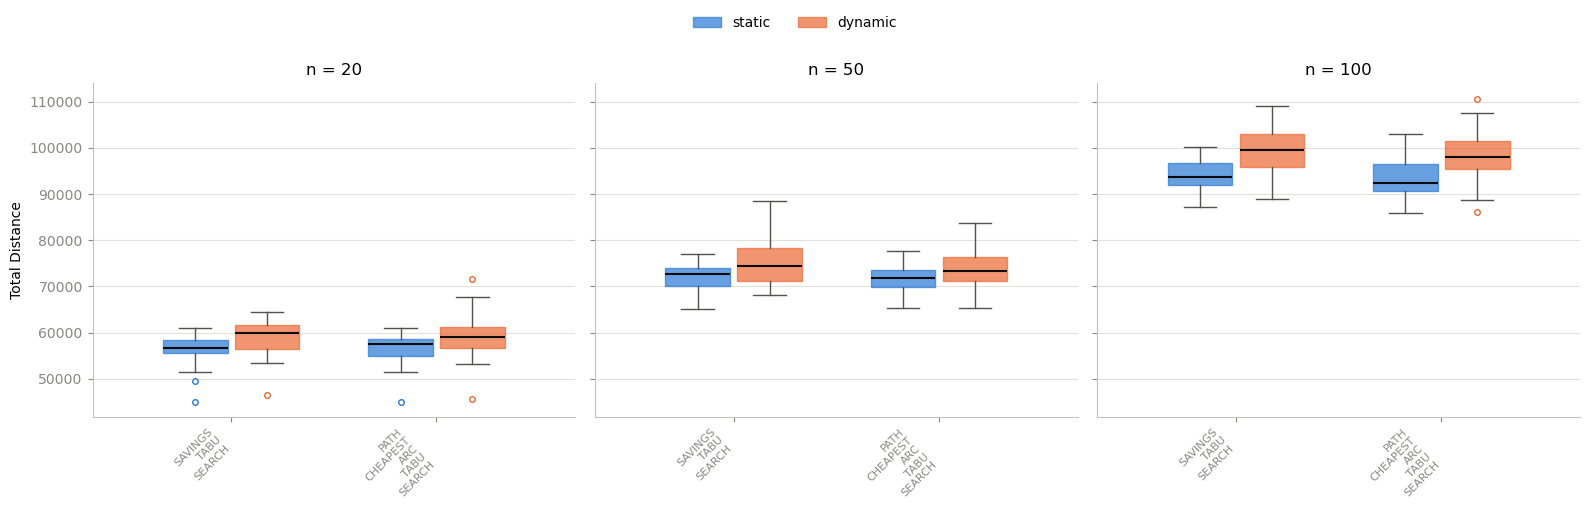

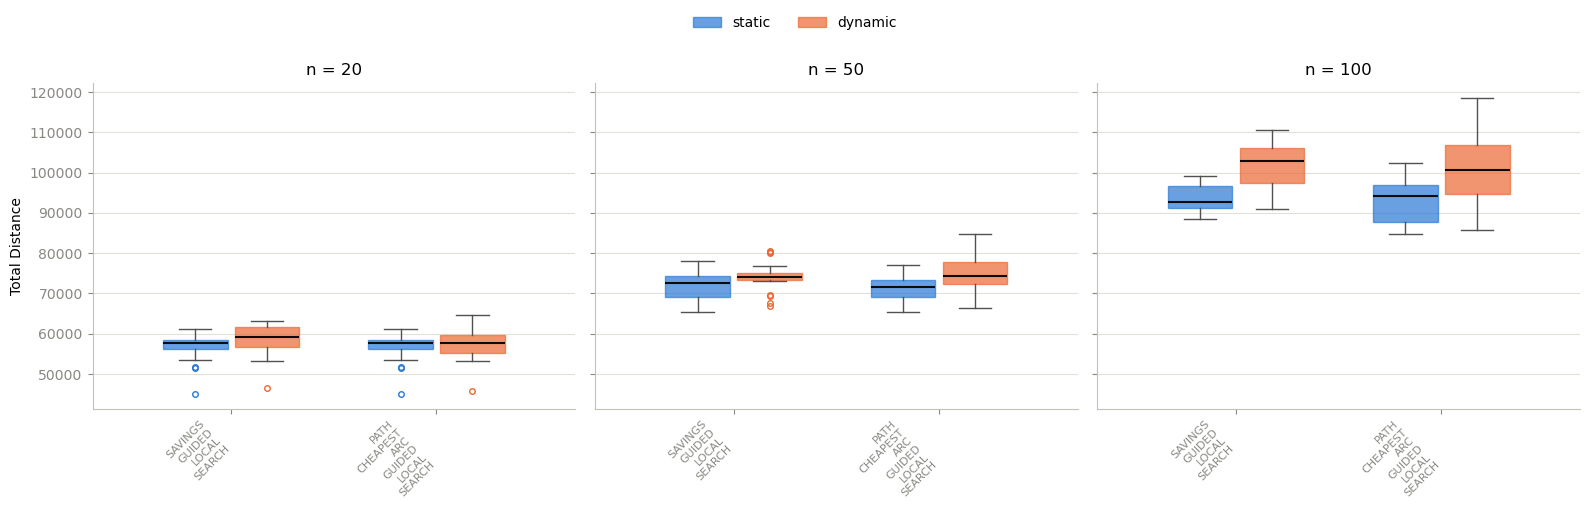

In [28]:
def plot_distance_group(strategies):
    strategy_labels = [s.replace("_", "\n") for s in strategies]
    x = np.arange(len(strategies))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, n in zip(axes, COUNTS):
        subset = all_runs[all_runs["num_static_customers"] == n]
        static_data = [
            subset[(subset["strategy"] == s) & (~subset["dynamic"])]["total_distance"]
            for s in strategies
        ]
        dynamic_data = [
            subset[(subset["strategy"] == s) & (subset["dynamic"])]["total_distance"]
            for s in strategies
        ]

        bp_static = ax.boxplot(
            static_data,
            positions=x - width / 2,
            widths=width * 0.9,
            patch_artist=True,
            medianprops={"color": "#0b0b0b", "linewidth": 1.5},
            boxprops={"facecolor": colors["static"], "edgecolor": colors["static"], "alpha": 0.7},
            whiskerprops={"color": "#52514e"},
            capprops={"color": "#52514e"},
            flierprops={"markeredgecolor": colors["static"], "markersize": 4},
        )
        bp_dynamic = ax.boxplot(
            dynamic_data,
            positions=x + width / 2,
            widths=width * 0.9,
            patch_artist=True,
            medianprops={"color": "#0b0b0b", "linewidth": 1.5},
            boxprops={"facecolor": colors["dynamic"], "edgecolor": colors["dynamic"], "alpha": 0.7},
            whiskerprops={"color": "#52514e"},
            capprops={"color": "#52514e"},
            flierprops={"markeredgecolor": colors["dynamic"], "markersize": 4},
        )

        ax.set_xticks(x)
        ax.set_xticklabels(strategy_labels, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"n = {n}")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#898781")
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Total Distance")

    fig.legend(
        [bp_static["boxes"][0], bp_dynamic["boxes"][0]],
        ["static", "dynamic"],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_distance_group(["SAVINGS", "PATH_CHEAPEST_ARC"])
plot_distance_group(["SAVINGS_TABU_SEARCH", "PATH_CHEAPEST_ARC_TABU_SEARCH"])
plot_distance_group(["SAVINGS_GUIDED_LOCAL_SEARCH", "PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH"])


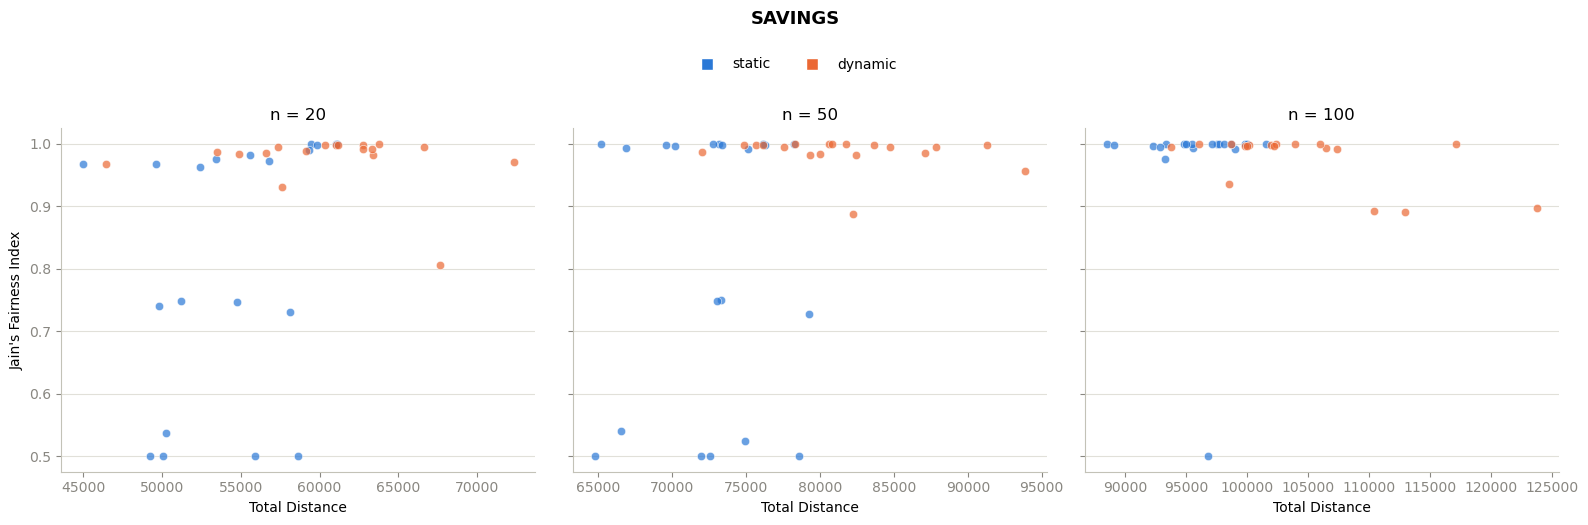

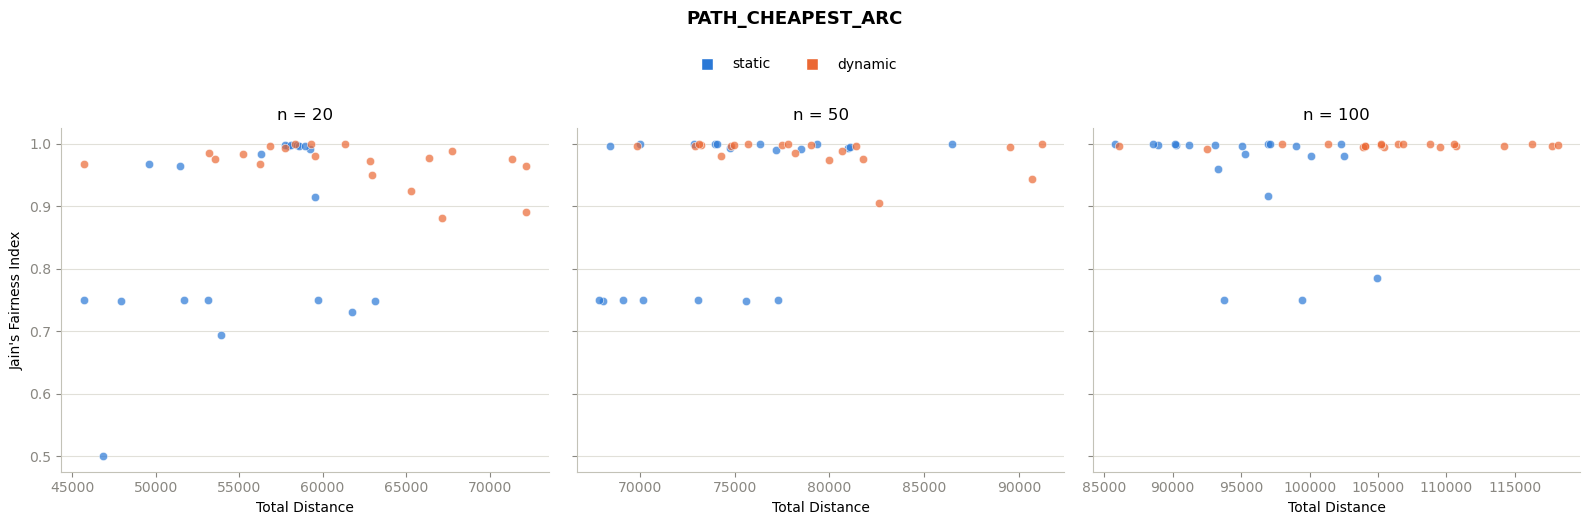

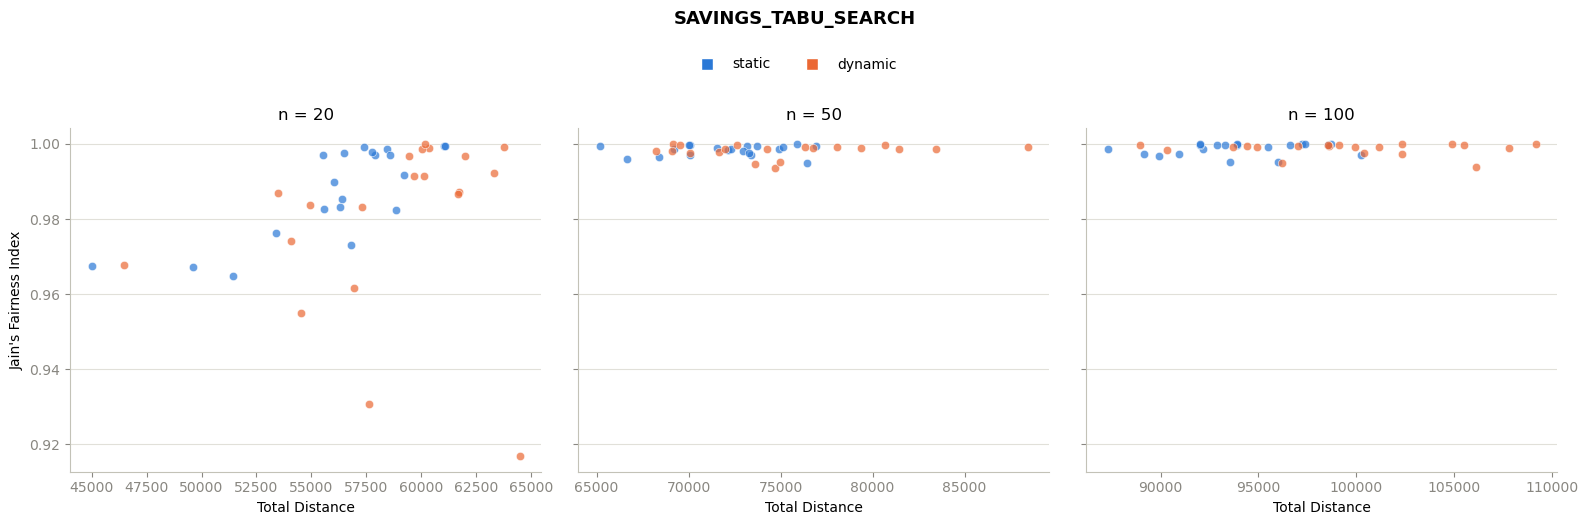

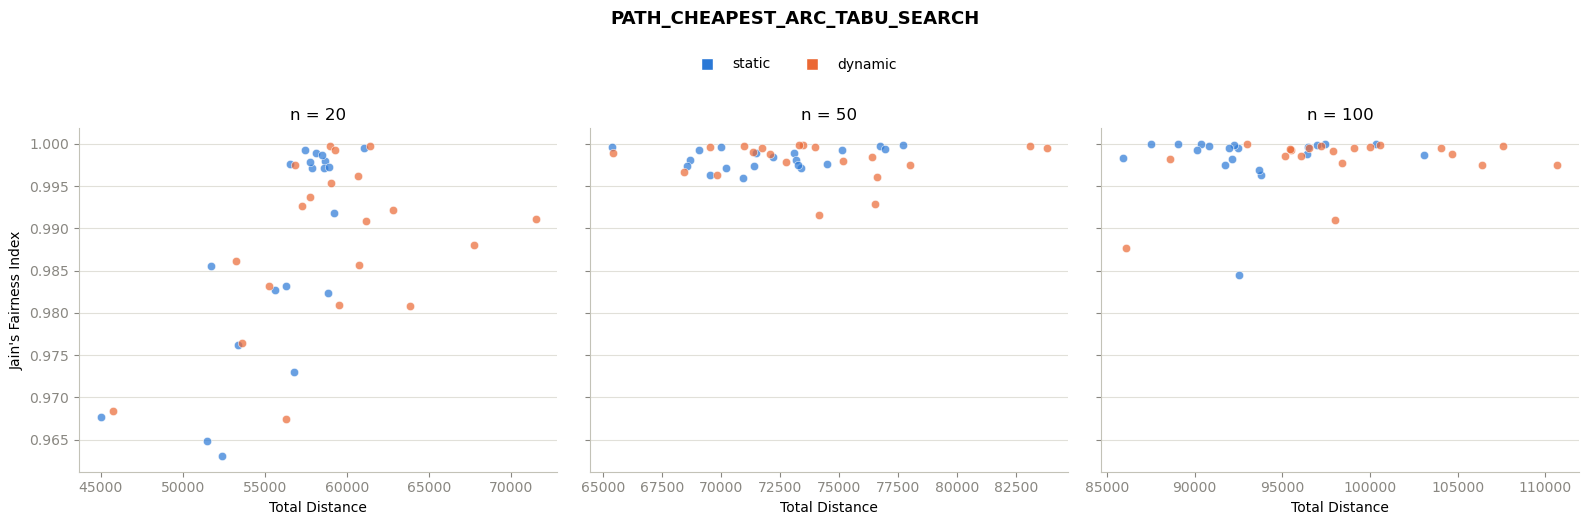

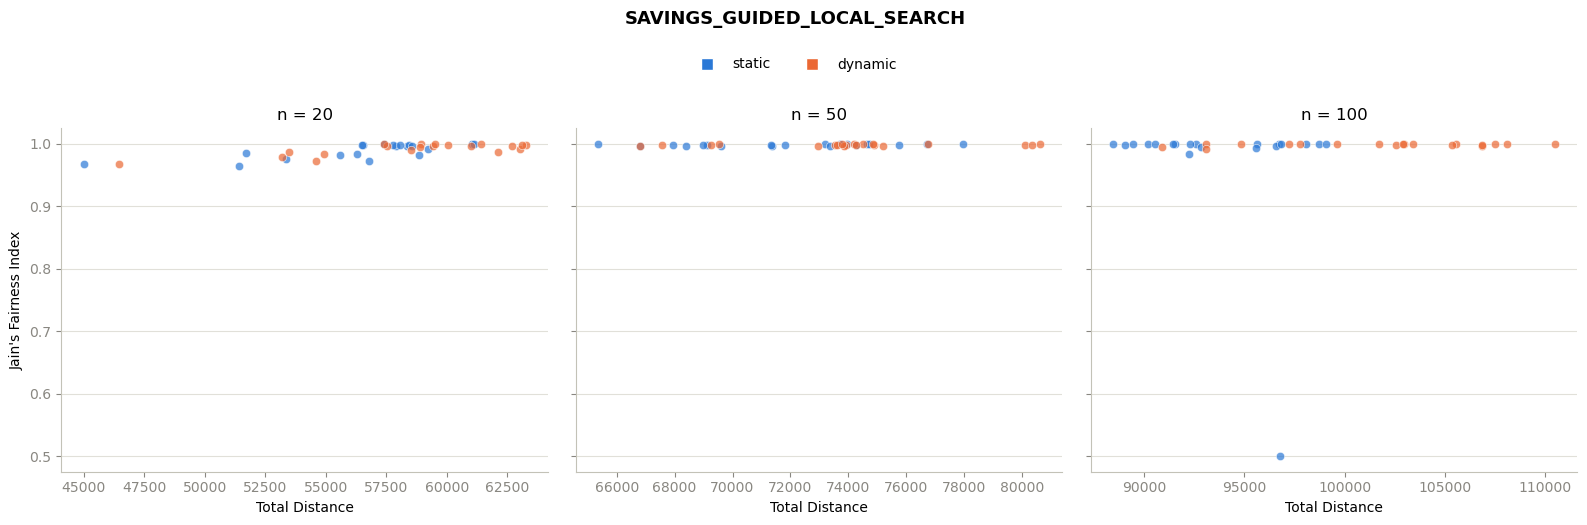

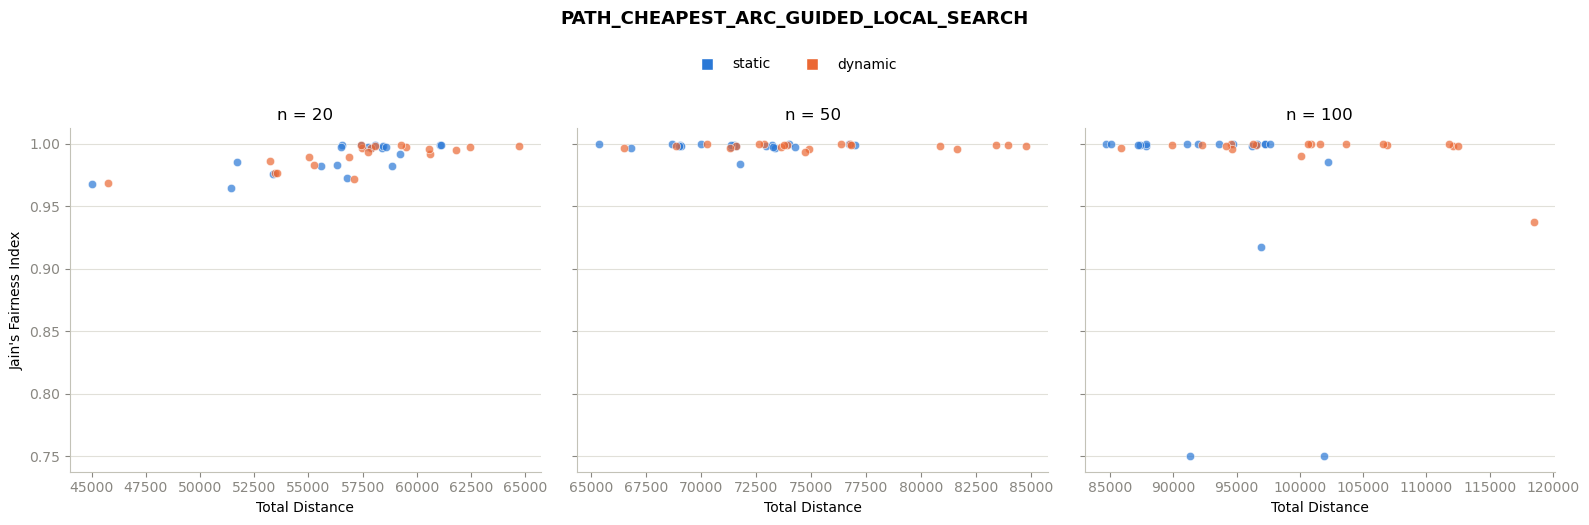

In [29]:
def plot_fairness_vs_distance(strategy):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, n in zip(axes, COUNTS):
        subset = all_runs[(all_runs["num_static_customers"] == n) & (all_runs["strategy"] == strategy)]
        for dynamic, kind in ((False, "static"), (True, "dynamic")):
            group = subset[subset["dynamic"] == dynamic]
            ax.scatter(
                group["total_distance"],
                group["jain_fairness_index"],
                color=colors[kind],
                alpha=0.7,
                edgecolor="white",
                linewidth=0.5,
            )
        ax.set_title(f"n = {n}")
        ax.set_xlabel("Total Distance")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#898781")
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Jain's Fairness Index")

    fig.suptitle(strategy, y=1.04, fontsize=13, fontweight="bold")

    color_handles = [
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=colors[k], markersize=8, label=k)
        for k in ("static", "dynamic")
    ]
    fig.legend(
        handles=color_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.97),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


for strategy in STRATEGIES:
    plot_fairness_vs_distance(strategy)


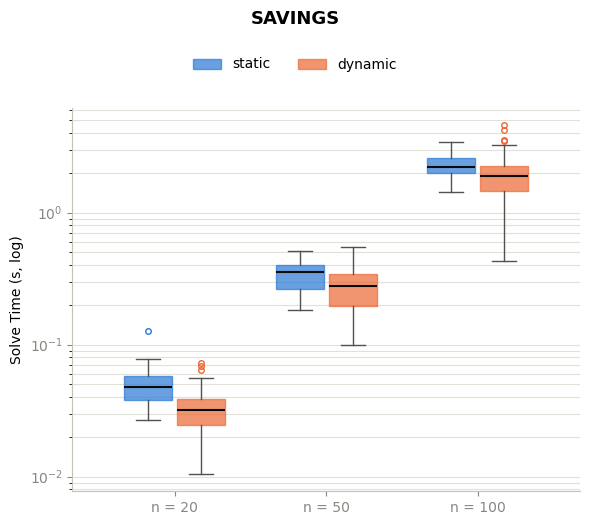

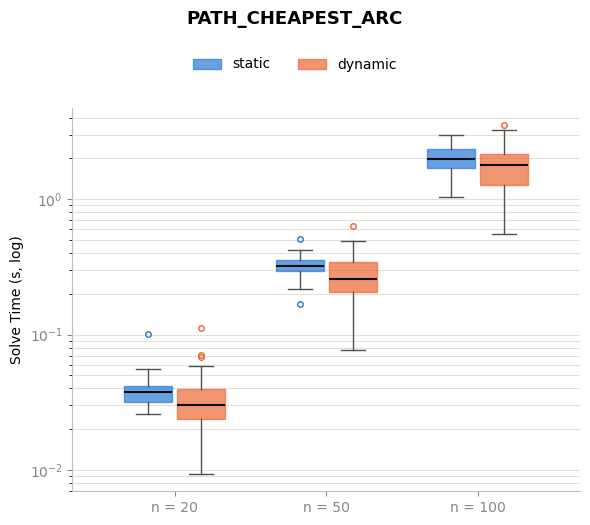

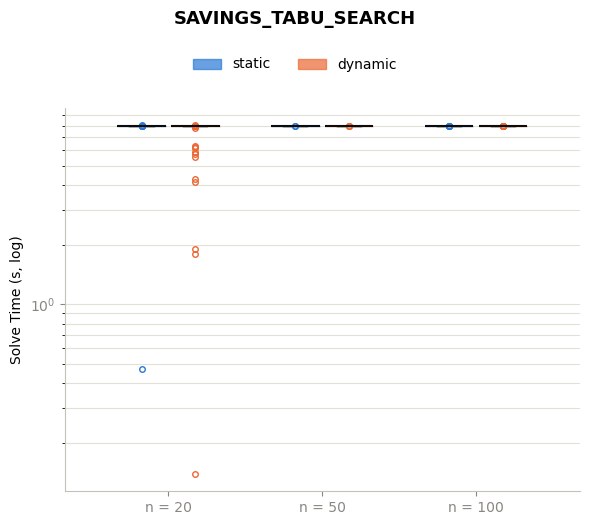

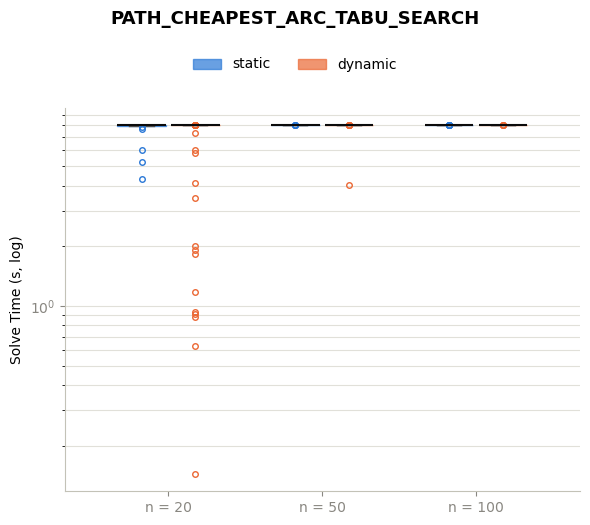

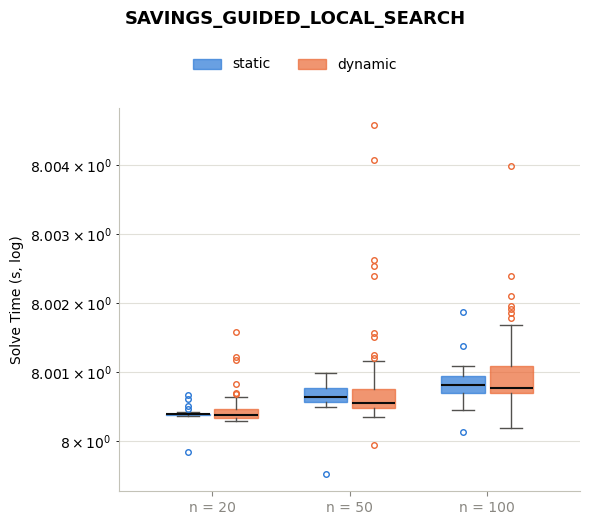

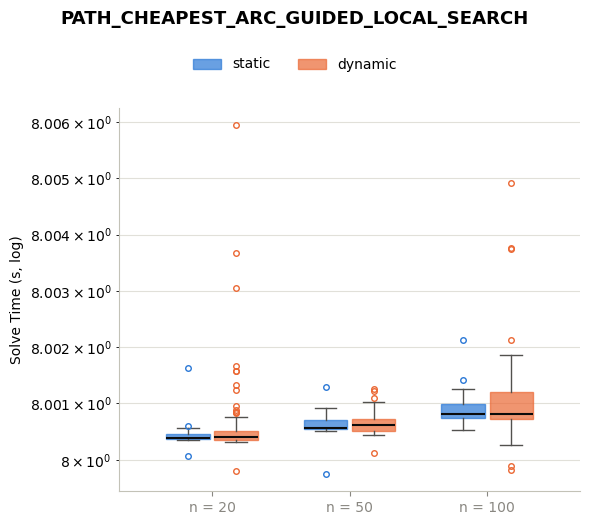

In [30]:
solve_times_df = (
    all_runs[["strategy", "dynamic", "num_static_customers", "solve_times"]]
    .explode("solve_times")
    .rename(columns={"solve_times": "solve_time"})
)
solve_times_df["solve_time"] = solve_times_df["solve_time"].astype(float)


def plot_solve_times_group(strategy):
    x = np.arange(len(COUNTS))

    fig, ax = plt.subplots(figsize=(6, 5))

    subset = solve_times_df[solve_times_df["strategy"] == strategy]
    static_data = [
        subset[(subset["num_static_customers"] == n) & (~subset["dynamic"])]["solve_time"]
        for n in COUNTS
    ]
    dynamic_data = [
        subset[(subset["num_static_customers"] == n) & (subset["dynamic"])]["solve_time"]
        for n in COUNTS
    ]

    bp_static = ax.boxplot(
        static_data,
        positions=x - width / 2,
        widths=width * 0.9,
        patch_artist=True,
        medianprops={"color": "#0b0b0b", "linewidth": 1.5},
        boxprops={"facecolor": colors["static"], "edgecolor": colors["static"], "alpha": 0.7},
        whiskerprops={"color": "#52514e"},
        capprops={"color": "#52514e"},
        flierprops={"markeredgecolor": colors["static"], "markersize": 4},
    )
    bp_dynamic = ax.boxplot(
        dynamic_data,
        positions=x + width / 2,
        widths=width * 0.9,
        patch_artist=True,
        medianprops={"color": "#0b0b0b", "linewidth": 1.5},
        boxprops={"facecolor": colors["dynamic"], "edgecolor": colors["dynamic"], "alpha": 0.7},
        whiskerprops={"color": "#52514e"},
        capprops={"color": "#52514e"},
        flierprops={"markeredgecolor": colors["dynamic"], "markersize": 4},
    )

    ax.set_xticks(x)
    ax.set_xticklabels([f"n = {n}" for n in COUNTS])
    ax.set_yscale("log")
    ax.set_ylabel("Solve Time (s, log)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")
    ax.yaxis.grid(True, which="both", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)

    fig.suptitle(strategy, y=1.04, fontsize=13, fontweight="bold")

    fig.legend(
        [bp_static["boxes"][0], bp_dynamic["boxes"][0]],
        ["static", "dynamic"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.97),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


for strategy in STRATEGIES:
    plot_solve_times_group(strategy)


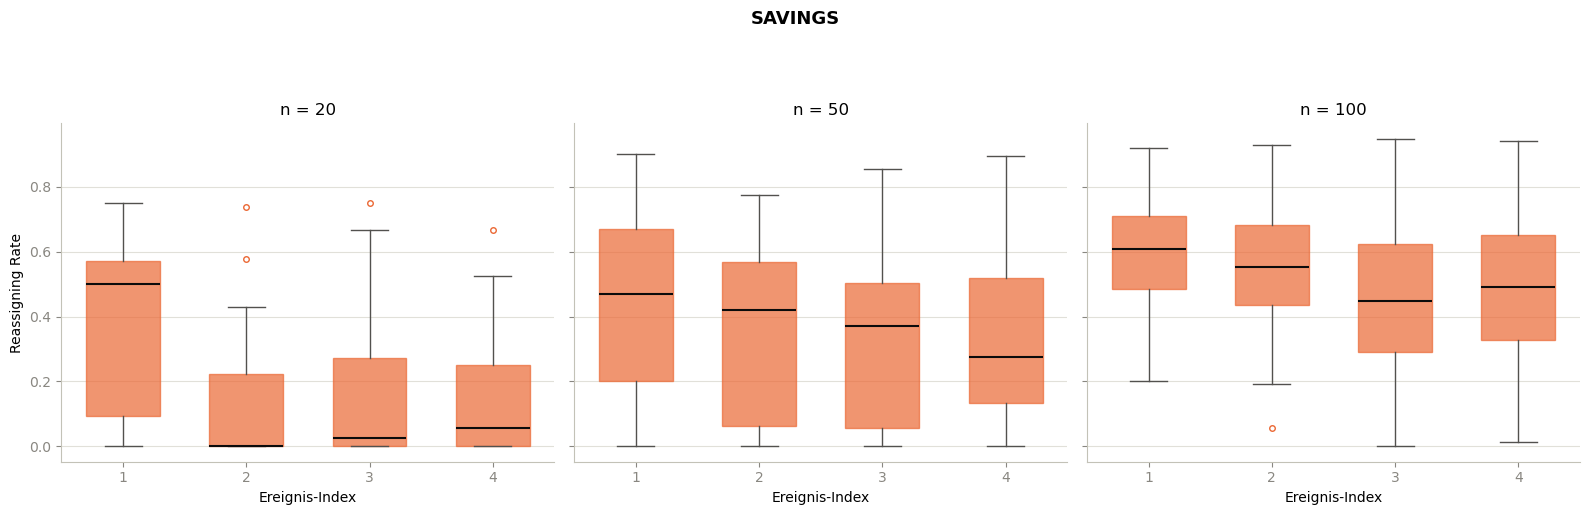

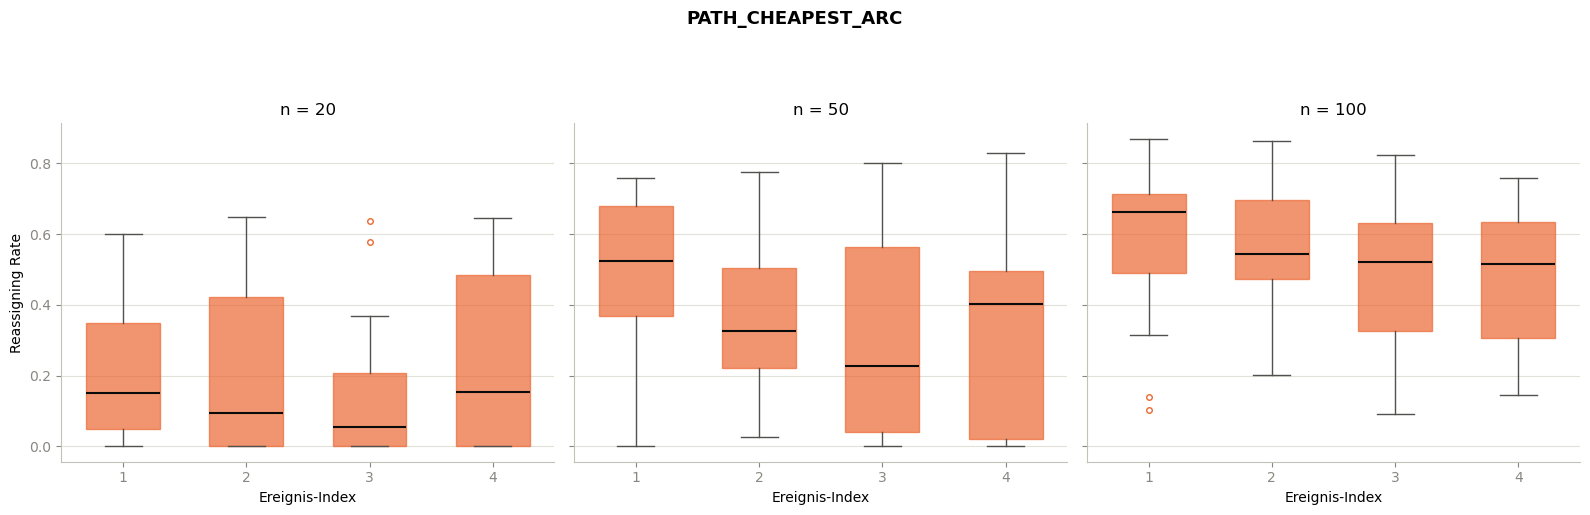

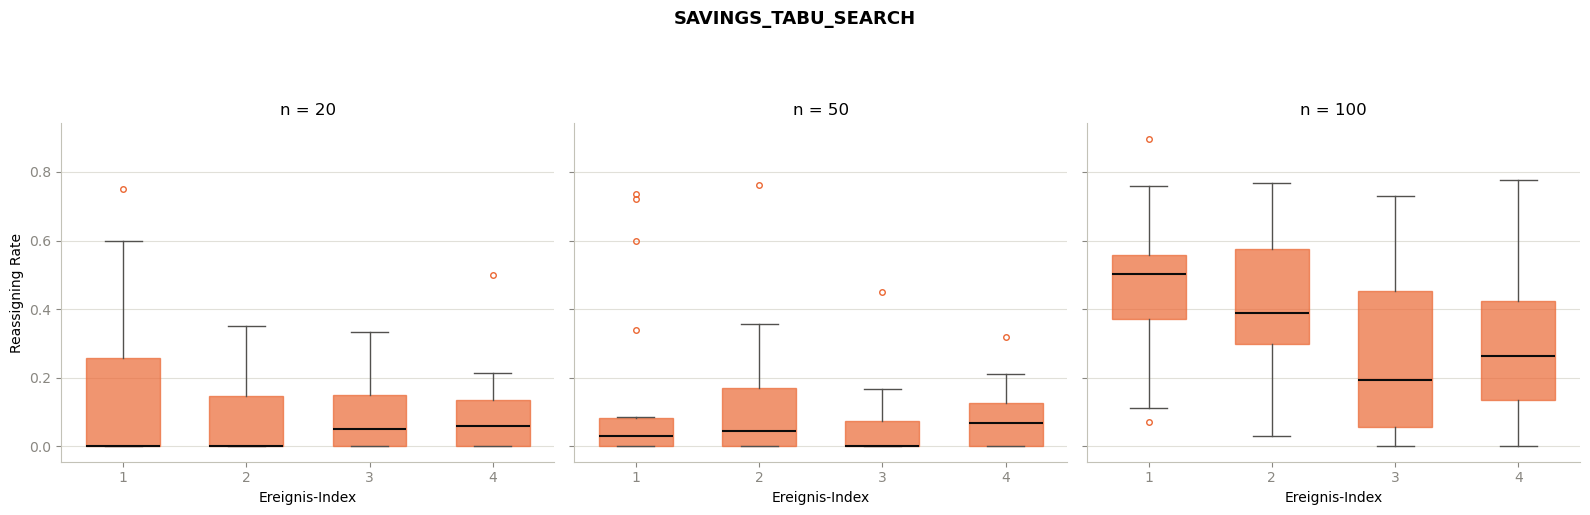

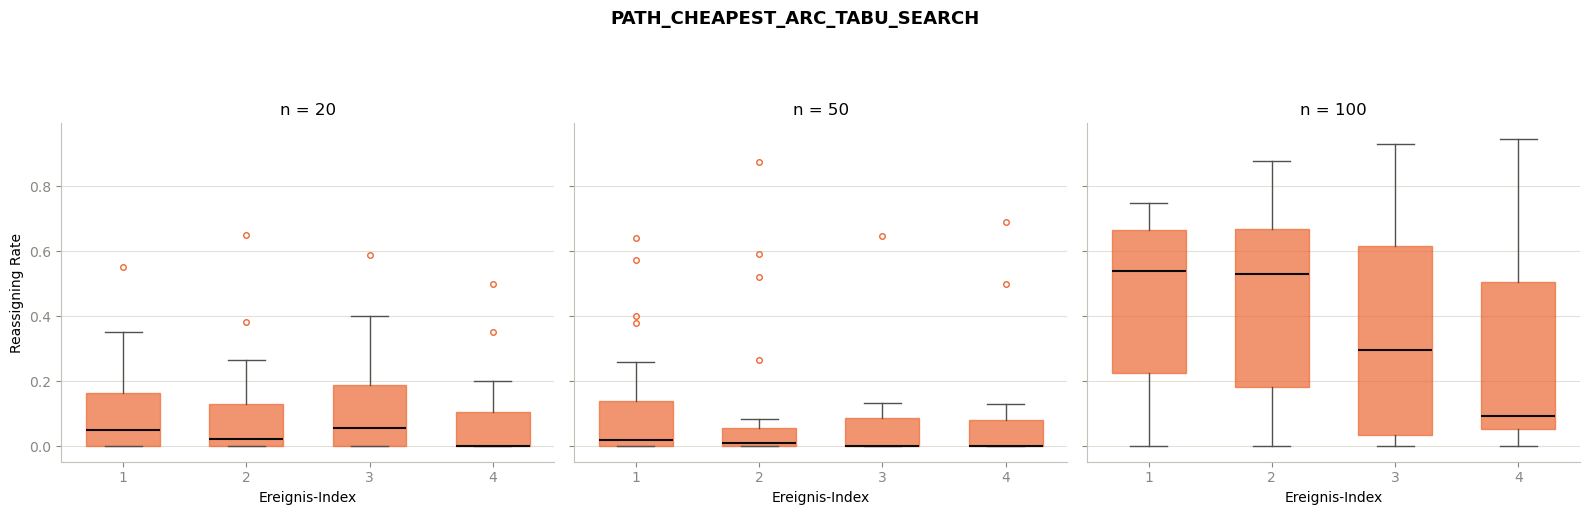

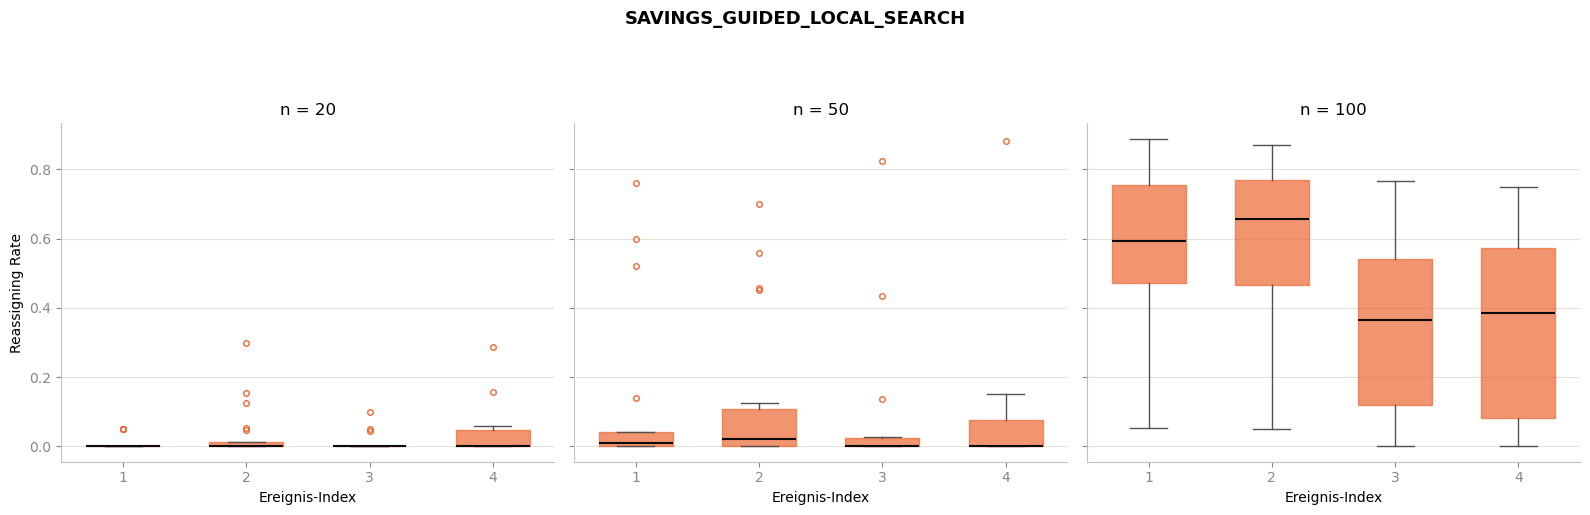

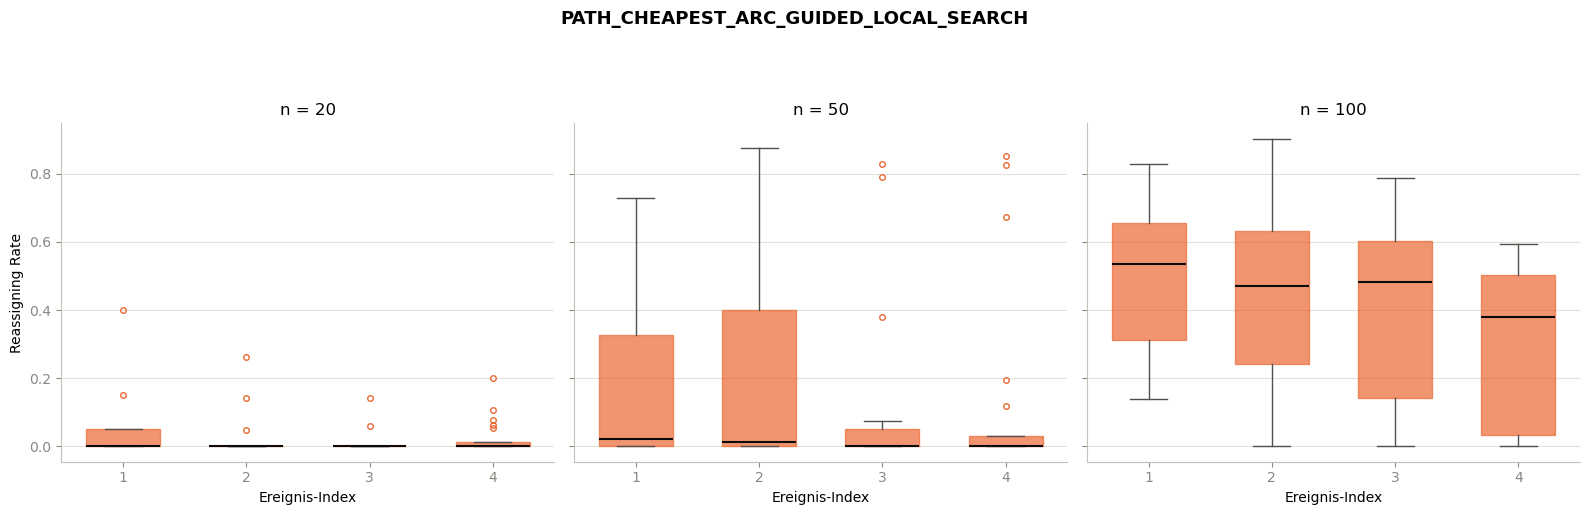

In [31]:
dynamic_runs = all_runs[all_runs["dynamic"]].copy()
dynamic_runs["event_index"] = dynamic_runs["reassigning_rates"].apply(lambda rr: list(range(1, len(rr) + 1)))

reassigning_df = (
    dynamic_runs[["strategy", "num_static_customers", "reassigning_rates", "event_index"]]
    .explode(["reassigning_rates", "event_index"])
    .rename(columns={"reassigning_rates": "reassigning_rate"})
)
reassigning_df["reassigning_rate"] = reassigning_df["reassigning_rate"].astype(float)
reassigning_df["event_index"] = reassigning_df["event_index"].astype(int)


def plot_reassigning_group(strategy):
    event_indices = [1, 2, 3, 4]
    x = np.arange(len(event_indices))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, n in zip(axes, COUNTS):
        subset = reassigning_df[
            (reassigning_df["strategy"] == strategy) & (reassigning_df["num_static_customers"] == n)
        ]
        data = [subset[subset["event_index"] == i]["reassigning_rate"] for i in event_indices]

        ax.boxplot(
            data,
            positions=x,
            widths=0.6,
            patch_artist=True,
            medianprops={"color": "#0b0b0b", "linewidth": 1.5},
            boxprops={"facecolor": colors["dynamic"], "edgecolor": colors["dynamic"], "alpha": 0.7},
            whiskerprops={"color": "#52514e"},
            capprops={"color": "#52514e"},
            flierprops={"markeredgecolor": colors["dynamic"], "markersize": 4},
        )

        ax.set_xticks(x)
        ax.set_xticklabels([str(i) for i in event_indices])
        ax.set_xlabel("Ereignis-Index")
        ax.set_title(f"n = {n}")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#898781")
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Reassigning Rate")

    fig.suptitle(strategy, y=1.02, fontsize=13, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


for strategy in STRATEGIES:
    plot_reassigning_group(strategy)
